# BiLSTM-CRF POS for Burmese language

## Pipeline

1. Read raw dataset
2. Parse sentences into words and POS tags
3. Split into train/validation/test
4. Build vocabularies
5. Encode sentences
6. Create Dataset and DataLoader
7. Build BiLSTM-CRF
8. Train the model
9. Evaluate the model
10. Predict POS tags for new sentences

Dataset format example: \
ကျွန်တော်/pron စာ/n ဖတ်/v သည်/ppm ။/punc

Dataset link: https://github.com/ye-kyaw-thu/myPOS/blob/master/corpus-ver-3.0/corpus/mypos-ver.3.0.shuf.nopipe.txt \
(EDIT: I didn't notice there was an open test corpus file. So, I trying evaluating the model with test file at the last index.)

- Should try hyper-parameter tuning
- I tried building the model with sklearn-crfsuite and the accuracy was 96%
- This BiLSTM-CRF model's score is 98.56% but the computation power is the tradeoff

## Loading libraries

In [1]:
import os
import random
import pickle
from collections import Counter

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

import torch
import torch.nn as nn
from torchcrf import CRF
import torch.optim as optim
from torch.utils.data import (
    Dataset,
    DataLoader,
)
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence,
    pad_packed_sequence,
)

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## GPU setup if available

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda


## Configuration

In [3]:
class Config:

    # Dataset
    DATA_PATH = "mypos-ver.3.0.shuf.nopipe.txt"

    # Split ratio
    TRAIN_SIZE = 0.8
    VALID_SIZE = 0.1
    TEST_SIZE = 0.1

    # Vocabulary
    MIN_FREQ = 1

    PAD_TOKEN = "<PAD>"
    UNK_TOKEN = "<UNK>"

    # Model
    EMBEDDING_DIM = 200
    HIDDEN_DIM = 128
    NUM_LAYERS = 2
    DROPOUT = 0.5

    # Training
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-4
    EPOCHS = 10
    CLIP = 5.0

    # Others
    RANDOM_SEED = 42
    SAVE_DIR = "outputs"
    MODEL_NAME = "bilstm_crf_best.pt"

config = Config()

## Output folder

In [4]:
os.makedirs(config.SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(config.SAVE_DIR, "checkpoints"), exist_ok=True)
os.makedirs(os.path.join(config.SAVE_DIR, "predictions"), exist_ok=True)
os.makedirs(os.path.join(config.SAVE_DIR, "logs"), exist_ok=True)
print("Folders created successfully.")

Folders created successfully.


## Set random seeds

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(config.RANDOM_SEED)

print(f"Random seed set to {config.RANDOM_SEED}")

Random seed set to 42


## Read the corpus

In [6]:
def read_corpus(filepath):
    """
    read corpus line by line.

    returns
    -------
    list[str]
        one sentence per list element.
    """

    with open(filepath, "r", encoding="utf-8") as f:
        lines = [
            line.strip()
            for line in f
            if line.strip()
        ]

    return lines

## Test

In [7]:
raw_sentences = read_corpus(config.DATA_PATH)
print("Number of sentences :", len(raw_sentences))
print()
print("First sentence:")
print(raw_sentences[0])

Number of sentences : 43196

First sentence:
၁၉၆၂/num ခုနှစ်/n ခန့်မှန်း/v သန်းခေါင်စာရင်း/n အရ/ppm လူဦးရေ/n ၁၁၅၉၃၁/num ယောက်/part ရှိ/v သည်/ppm ။/punc


## Parsing the sentences into word and tag

In [8]:
def parse_sentence(sentence):
    """
    convert the corpus into words and tags lits
    """
    words = []
    tags = []

    tokens = sentence.split()
    
    for token in tokens:
        if "/" not in token:
            continue

        word, tag = token.rsplit("/", 1)
        words.append(word)
        tags.append(tag)

    return words, tags

## Testing the parser

In [9]:
words, tags = parse_sentence(raw_sentences[0])

print(words)
print()
print(tags)

['၁၉၆၂', 'ခုနှစ်', 'ခန့်မှန်း', 'သန်းခေါင်စာရင်း', 'အရ', 'လူဦးရေ', '၁၁၅၉၃၁', 'ယောက်', 'ရှိ', 'သည်', '။']

['num', 'n', 'v', 'n', 'ppm', 'n', 'num', 'part', 'v', 'ppm', 'punc']


## Parsing the entire corpus

In [10]:
sentences = []
labels = []

for sentence in raw_sentences:
    words, tags = parse_sentence(sentence)
    if len(words) == 0:
        continue

    sentences.append(words)
    labels.append(tags)

print("Parsed sentences :", len(sentences))

Parsed sentences : 43196


## Dataset statistics

In [11]:
num_sentences = len(sentences)

sentence_lengths = [
    len(s)
    for s in sentences
]

num_tokens = sum(sentence_lengths)
avg_length = np.mean(sentence_lengths)
max_length = max(sentence_lengths)
min_length = min(sentence_lengths)

print("=" * 50)
print("Dataset Statistics")
print("=" * 50)

print(f"Sentences          : {num_sentences}")
print(f"Tokens             : {num_tokens}")
print(f"Average Length     : {avg_length:.2f}")
print(f"Maximum Length     : {max_length}")
print(f"Minimum Length     : {min_length}")

Dataset Statistics
Sentences          : 43196
Tokens             : 564517
Average Length     : 13.07
Maximum Length     : 423
Minimum Length     : 1


## Data integrity check
(I believe the dataset is already cleaned but I added this to make sure)

In [12]:
for i in range(len(sentences)):

    assert len(sentences[i]) == len(labels[i]), \
        f"Mismatch at sentence {i}"

print("All sentences are valid.")

All sentences are valid.


## train/test/val split

In [13]:
# First split: Train (80%) and Temp (20%)
train_sentences, temp_sentences, train_tags, temp_tags = train_test_split(
    sentences,
    labels,
    test_size=(1 - config.TRAIN_SIZE),
    random_state=config.RANDOM_SEED,
    shuffle=True
)

# Second split: Temp -> Validation (10%) and Test (10%)
valid_sentences, test_sentences, valid_tags, test_tags = train_test_split(
    temp_sentences,
    temp_tags,
    test_size=0.5,
    random_state=config.RANDOM_SEED,
    shuffle=True
)

print("Train :", len(train_sentences))
print("Valid :", len(valid_sentences))
print("Test  :", len(test_sentences))

Train : 34556
Valid : 4320
Test  : 4320


## Building the word vocabulary

In [14]:
word_counter = Counter()

for sentence in train_sentences:
    word_counter.update(sentence)

print("Unique words :", len(word_counter))

Unique words : 21999


In [15]:
word2idx = {
    config.PAD_TOKEN: 0,
    config.UNK_TOKEN: 1
}

for word, freq in word_counter.items():

    if freq >= config.MIN_FREQ:
        word2idx[word] = len(word2idx)

idx2word = {
    idx: word for word, idx in word2idx.items()
}

print("Vocabulary size :", len(word2idx))

Vocabulary size : 22001


## Building the tag vocab

In [16]:
tag_counter = Counter()

for tags in train_tags:
    tag_counter.update(tags)

print(tag_counter)

Counter({'part': 108565, 'n': 98665, 'ppm': 69461, 'v': 67469, 'punc': 43326, 'pron': 16392, 'conj': 14334, 'adj': 13138, 'adv': 8544, 'num': 4768, 'tn': 4672, 'fw': 2630, 'int': 535, 'abb': 291, 'sb': 214})


In [17]:
tag2idx = {}

for tag in sorted(tag_counter.keys()):
    tag2idx[tag] = len(tag2idx)

idx2tag = {
    idx: tag for tag, idx in tag2idx.items()
}

print(tag2idx)

{'abb': 0, 'adj': 1, 'adv': 2, 'conj': 3, 'fw': 4, 'int': 5, 'n': 6, 'num': 7, 'part': 8, 'ppm': 9, 'pron': 10, 'punc': 11, 'sb': 12, 'tn': 13, 'v': 14}


## Vocab statistics

In [18]:
print("="*50)
print("Vocabulary Statistics")
print("="*50)
print(f"Word Vocabulary : {len(word2idx)}")
print(f"Tag Vocabulary  : {len(tag2idx)}")
print(f"PAD index       : {word2idx[config.PAD_TOKEN]}")
print(f"UNK index       : {word2idx[config.UNK_TOKEN]}")

Vocabulary Statistics
Word Vocabulary : 22001
Tag Vocabulary  : 15
PAD index       : 0
UNK index       : 1


## Sentence encoder

In [19]:
def encode_words(sentence, word2idx):
    """
    Convert words to integer IDs.
    Unknown words become UNK.
    """
    return [
        word2idx.get(word, word2idx[config.UNK_TOKEN])
        for word in sentence
    ]

def encode_tags(tags, tag2idx):
    """
    Convert POS tags to integer IDs.
    """
    return [
        tag2idx[tag]
        for tag in tags
    ]

## Encoding train/val/test

In [20]:
train_inputs = [
    encode_words(s, word2idx)
    for s in train_sentences
]

valid_inputs = [
    encode_words(s, word2idx)
    for s in valid_sentences
]

test_inputs = [
    encode_words(s, word2idx)
    for s in test_sentences
]

train_outputs = [
    encode_tags(t, tag2idx)
    for t in train_tags
]

valid_outputs = [
    encode_tags(t, tag2idx)
    for t in valid_tags
]

test_outputs = [
    encode_tags(t, tag2idx)
    for t in test_tags
]

## Creating POSDataset

In [21]:
class POSDataset(Dataset):
    """
    tensors for pos tagging
    """

    def __init__(self, inputs, labels):
        """
        Parameters
        ----------
        inputs : List[List[int]]
            Encoded word IDs.

        labels : List[List[int]]
            Encoded tag IDs.
        """

        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.inputs[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [22]:
train_dataset = POSDataset(train_inputs, train_outputs)
print("Training samples:", len(train_dataset))

Training samples: 34556


## Printing one sample

In [23]:
words, tags = train_dataset[0]

print("Word IDs")
print(words)

print()

print("Tag IDs")
print(tags)

Word IDs
tensor([2, 3, 4, 5])

Tag IDs
tensor([ 6, 14,  9, 11])


## Padding stage

In [24]:
def collate_fn(batch):
    """
    pads sequences in a batch.

    returns
    -------
    padded_inputs
    padded_labels
    lengths
    mask
    """

    inputs = [item[0] for item in batch]
    labels = [item[1] for item in batch]

    # original sequence lengths
    lengths = torch.tensor(
        [len(seq) for seq in inputs],
        dtype=torch.long
    )

    # pad input sequences
    padded_inputs = pad_sequence(
        inputs,
        batch_first=True,
        padding_value=word2idx[config.PAD_TOKEN]
    )

    # pad label sequences
    padded_labels = pad_sequence(
        labels,
        batch_first=True,
        padding_value=0
    )

    # Mask: True for real tokens, False for padding
    mask = padded_inputs != word2idx[config.PAD_TOKEN]

    return (
        padded_inputs,
        padded_labels,
        lengths,
        mask
    )

## Testinng the collate function

In [25]:
sample_batch = [
    train_dataset[0],
    train_dataset[1],
    train_dataset[2]
]

inputs, labels, lengths, mask = collate_fn(sample_batch)
print("Inputs Shape :", inputs.shape)
print("Labels Shape :", labels.shape)
print("Lengths Shape:", lengths.shape)
print("Mask Shape   :", mask.shape)
print()
print(inputs)
print()
print(mask)

Inputs Shape : torch.Size([3, 22])
Labels Shape : torch.Size([3, 22])
Lengths Shape: torch.Size([3])
Mask Shape   : torch.Size([3, 22])

tensor([[ 2,  3,  4,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0],
        [ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
         24, 25, 26,  5],
        [27, 28, 29, 30,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0]])

tensor([[ True,  True,  True,  True, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True],
        [ True,  True,  True,  True,  True, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, Fa

## Create the dataset objects

In [26]:
train_dataset = POSDataset(
    train_inputs,
    train_outputs
)

valid_dataset = POSDataset(
    valid_inputs,
    valid_outputs
)

test_dataset = POSDataset(
    test_inputs,
    test_outputs
)

## Create the data loaders

In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [28]:
batch = next(iter(train_loader))
inputs, labels, lengths, mask = batch

print(inputs.shape)
print(labels.shape)
print(lengths.shape)
print(mask.shape)

torch.Size([32, 45])
torch.Size([32, 45])
torch.Size([32])
torch.Size([32, 45])


## Building the model

In [29]:
class BiLSTMCRF(nn.Module):

    def __init__(
        self,
        vocab_size,
        tagset_size,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout,
        pad_idx,
    ):

        super().__init__()

        # embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx,
        )

        # bi-lstm layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
        )

        # dropout layer
        self.dropout = nn.Dropout(dropout)

        # linear layer
        self.fc = nn.Linear(
            hidden_dim * 2,
            tagset_size,
        )

        # crf layer
        self.crf = CRF(
            tagset_size,
            batch_first=True,
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for name, param in self.named_parameters():
            if "weight" in name and param.dim() > 1:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

    def forward(self,input_ids,tags,mask):
        embeddings = self.embedding(input_ids)
        lstm_out, _ = self.lstm(embeddings)
        lstm_out = self.dropout(lstm_out)
        emissions = self.fc(lstm_out)
        loss = -self.crf(
            emissions,
            tags,
            mask=mask,
            reduction="mean",
        )
        return loss

    def decode(self,input_ids,mask):
        embeddings = self.embedding(input_ids)
        lstm_out, _ = self.lstm(embeddings)
        lstm_out = self.dropout(lstm_out)
        emissions = self.fc(lstm_out)
        prediction = self.crf.decode(
            emissions,
            mask=mask,
        )
        return prediction
        

In [30]:
model = BiLSTMCRF(
    vocab_size=len(word2idx),
    tagset_size=len(tag2idx),
    embedding_dim=config.EMBEDDING_DIM,
    hidden_dim=config.HIDDEN_DIM,
    num_layers=config.NUM_LAYERS,
    dropout=config.DROPOUT,
    pad_idx=word2idx[config.PAD_TOKEN],
)
model = model.to(device)
print(model)

BiLSTMCRF(
  (embedding): Embedding(22001, 200, padding_idx=0)
  (lstm): LSTM(200, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=15, bias=True)
  (crf): CRF(num_tags=15)
)


In [31]:
batch = next(iter(train_loader))

input_ids, tags, lengths, mask = batch

input_ids = input_ids.to(device)
tags = tags.to(device)
mask = mask.to(device)

loss = model(
    input_ids,
    tags,
    mask,
)

print(loss)

tensor(41.0149, device='cuda:0', grad_fn=<NegBackward0>)


## Setting up the citerion and learning rate schedular

In [32]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

## Train function

In [33]:
from tqdm.auto import tqdm

def train_one_epoch(model, dataloader, optimizer, device):

    model.train()

    total_loss = 0.0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for input_ids, tags, lengths, mask in progress_bar:

        input_ids = input_ids.to(device)
        tags = tags.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()

        loss = model(
            input_ids=input_ids,
            tags=tags,
            mask=mask
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return total_loss / len(dataloader)

## Validation function

In [34]:
def validate(model, dataloader, device):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        progress_bar = tqdm(
            dataloader,
            desc="Validation",
            leave=False
        )

        for input_ids, tags, lengths, mask in progress_bar:

            input_ids = input_ids.to(device)
            tags = tags.to(device)
            mask = mask.to(device)

            loss = model(
                input_ids=input_ids,
                tags=tags,
                mask=mask
            )

            total_loss += loss.item()

    return total_loss / len(dataloader)

## Complete training

In [35]:
train_losses = []
val_losses = []

for epoch in range(config.EPOCHS):

    print(f"\nEpoch {epoch+1}/{config.EPOCHS}")

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device,
    )

    val_loss = validate(
        model,
        valid_loader,
        device,
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Valid Loss : {val_loss:.4f}")


Epoch 1/10


Train Loss : 4.8807
Valid Loss : 2.0925

Epoch 2/10


Train Loss : 1.7785
Valid Loss : 1.9138

Epoch 3/10


Train Loss : 1.4343
Valid Loss : 1.8239

Epoch 4/10


Train Loss : 1.2250
Valid Loss : 1.8209

Epoch 5/10


...

Train Loss : 0.9507
Valid Loss : 2.0393

Epoch 7/10


Train Loss : 0.8398
Valid Loss : 2.0625

Epoch 8/10


Train Loss : 0.6543
Valid Loss : 2.2274

Epoch 9/10


Train Loss : 0.5645
Valid Loss : 2.4192

Epoch 10/10


Train Loss : 0.5071
Valid Loss : 2.5344


## Plotting the loss curve

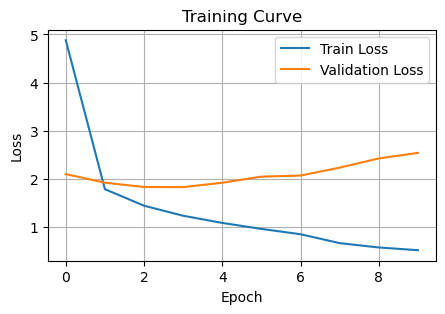

In [44]:
plt.figure(figsize=(5,3))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

## Prediction function

In [37]:
def predict(model, dataloader, device):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for input_ids, tags, lengths, mask in tqdm(dataloader):

            input_ids = input_ids.to(device)
            mask = mask.to(device)

            predictions = model.decode(
                input_ids=input_ids,
                mask=mask
            )

            tags = tags.cpu().numpy()
            mask = mask.cpu().numpy()

            for pred, gold, m in zip(predictions, tags, mask):

                length = m.sum()

                all_predictions.extend(pred[:length])
                all_labels.extend(gold[:length])

    return all_labels, all_predictions

In [38]:
true_labels, pred_labels = predict(
    model,
    test_loader,
    device
)

100%|██████████| 135/135 [00:05<00:00, 23.76it/s]


## Token accuracy

In [39]:
accuracy = accuracy_score(
    true_labels,
    pred_labels
)

print(f"Token Accuracy: {accuracy:.4f}")

Token Accuracy: 0.9592


## precision/recall/f1

In [40]:
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    pred_labels,
    average="weighted"
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Precision : 0.9590
Recall    : 0.9592
F1-score  : 0.9590


## Classification report

In [41]:
tag_names = [
    idx2tag[i]
    for i in range(len(idx2tag))
]

print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=tag_names,
        digits=4,
    )
)

              precision    recall  f1-score   support

         abb     0.9677    0.7143    0.8219        42
         adj     0.8382    0.8171    0.8275      1629
         adv     0.8721    0.8520    0.8619      1088
        conj     0.9093    0.9193    0.9143      1734
          fw     0.8289    0.6321    0.7173       299
         int     0.9059    0.8851    0.8953        87
           n     0.9554    0.9598    0.9576     12050
         num     0.9855    0.9186    0.9509       590
        part     0.9718    0.9706    0.9712     13383
         ppm     0.9787    0.9867    0.9827      8520
        pron     0.9743    0.9612    0.9677      2009
        punc     0.9994    0.9994    0.9994      5445
          sb     1.0000    0.9474    0.9730        19
          tn     0.9688    0.9672    0.9680       609
           v     0.9408    0.9511    0.9459      8274

    accuracy                         0.9592     55778
   macro avg     0.9398    0.8988    0.9170     55778
weighted avg     0.9590   

## Confusion matrix

In [42]:
cm = confusion_matrix(
    true_labels,
    pred_labels
)

[[   30     0     1     0     0     0    11     0     0     0     0     0
      0     0     0]
 [    0  1331    40    14     2     0    69     0    18     0    21     0
      0     3   131]
 [    0    39   927     1     1     0    75     0     5     0     1     0
      0     0    39]
 [    0     3     4  1594     0     0     5     0    42    80     0     2
      0     0     4]
 [    1     2     3     0   189     0   100     0     0     0     0     0
      0     0     4]
 [    0     0     0     0     0    77     4     0     6     0     0     0
      0     0     0]
 [    0    76    59     5    28     4 11566     6    79    18    27     0
      0    14   168]
 [    0     1     2     0     5     0    39   542     0     0     0     0
      0     0     1]
 [    0    14     4    81     0     1    74     1 12990    73     2     1
      0     1   141]
 [    0     0     0    50     0     0     5     0    53  8407     0     0
      0     0     5]
 [    0    29     4     0     0     3    28     0 

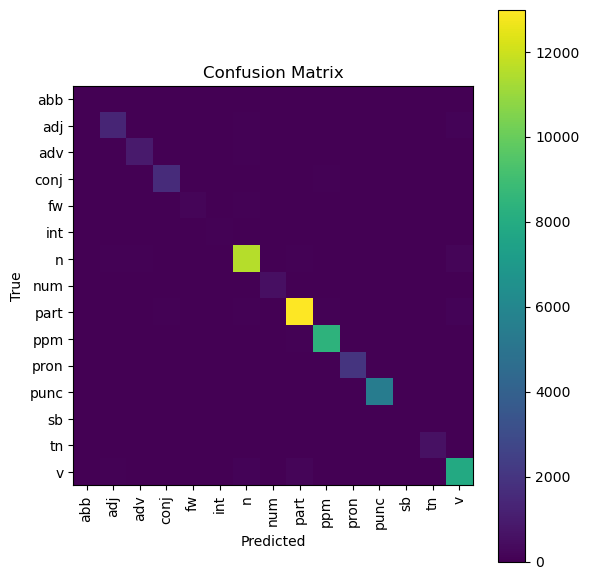

In [46]:
plt.figure(figsize=(6, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(
    range(len(tag_names)),
    tag_names,
    rotation=90
)
plt.yticks(
    range(len(tag_names)),
    tag_names
)

plt.colorbar()
plt.tight_layout()
plt.show()

## Predict new sentence

In [48]:
def predict_sentence(
    sentence,
    model,
    word2idx,
    idx2tag,
    device,
    unk_token="<UNK>",
):
    """
    Predict POS tags for a Space-separated sentence.
    returns list of (word, predicted_tag)
    """

    model.eval()
    tokens = sentence.strip().split()
    input_ids = [word2idx.get(word, word2idx[unk_token]) for word in tokens]
    input_ids = torch.tensor(
        [input_ids],
        dtype=torch.long,
        device=device
    )
    mask = torch.ones_like(
        input_ids,
        dtype=torch.bool
    )


    with torch.no_grad():
        prediction = model.decode(
            input_ids=input_ids,
            mask=mask
        )[0]

    predicted_tags = [
        idx2tag[idx]
        for idx in prediction
    ]

    return list(zip(tokens, predicted_tags))

Prof. Ye Kyaw Thu's sylbreak will be quite handy as the function needs space-separated Burmese words \
https://github.com/ye-kyaw-thu/sylbreak

In [55]:
sent1 = "မြန်မာစာ ကို ချစ် ပါ"
sent2 = "မြန်မာစာ ကို မြတ်နိုး ပါ"
sent3 = "သုတေသန များ ဆောင်ရွက် ပါ ။"

result = predict_sentence(
    sent3,
    model,
    word2idx,
    idx2tag,
    device,
)

for word, tag in result:
    print(f"{word:<20} {tag}")

သုတေသန               n
များ                 part
ဆောင်ရွက်            v
ပါ                   part
။                    punc


# Trying the evaluation with the open test file
Dataset link -> https://github.com/ye-kyaw-thu/myPOS/blob/master/corpus-ver-3.0/corpus/otest.1k.nopipe.txt

## file loading and parsing

In [56]:
TEST_FILE = "otest.1k.nopipe.txt"

with open(TEST_FILE, "r", encoding="utf-8") as f:
    raw_test_sentences = [
        line.strip()
        for line in f
        if line.strip()
    ]

print("Test sentences:", len(raw_test_sentences))

test_sentences = []
test_tags = []

for sentence in raw_test_sentences:
    words, tags = parse_sentence(sentence)

    if len(words) == 0:
        continue

    test_sentences.append(words)
    test_tags.append(tags)

print("Parsed test sentences:", len(test_sentences))

Test sentences: 1000
Parsed test sentences: 1000


## Encode

In [57]:
encoded_test_inputs = [
    encode_words(sentence, word2idx)
    for sentence in test_sentences
]

encoded_test_labels = [
    encode_tags(tags, tag2idx)
    for tags in test_tags
]

## Dataset & DataLoader

In [58]:
official_test_dataset = POSDataset(
    encoded_test_inputs,
    encoded_test_labels
)

official_test_loader = DataLoader(
    official_test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

## Predict

In [59]:
true_labels, pred_labels = predict(
    model,
    official_test_loader,
    device
)

100%|██████████| 32/32 [00:01<00:00, 21.22it/s]


## Accuray for the open test file

In [60]:
accuracy = accuracy_score(
    true_labels,
    pred_labels
)

print(f"Official Test Accuracy: {accuracy:.4f}")

Official Test Accuracy: 0.9856


## Precision / Recall / F1 for the open test file

In [61]:
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    pred_labels,
    average="weighted"
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Precision : 0.9856
Recall    : 0.9856
F1-score  : 0.9856


## Classification report of the open test file

In [62]:
print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=tag_names,
        digits=4
    )
)

              precision    recall  f1-score   support

         abb     1.0000    1.0000    1.0000        12
         adj     0.9448    0.9344    0.9396       366
         adv     0.9567    0.9275    0.9419       262
        conj     0.9729    0.9611    0.9670       411
          fw     0.9762    0.9425    0.9591        87
         int     0.9600    0.9600    0.9600        25
           n     0.9913    0.9863    0.9888      3000
         num     1.0000    0.9935    0.9968       155
        part     0.9890    0.9893    0.9892      3189
         ppm     0.9893    0.9903    0.9898      2060
        pron     0.9812    0.9874    0.9843       476
        punc     1.0000    1.0000    1.0000      1270
          sb     1.0000    1.0000    1.0000         3
          tn     0.9792    0.9930    0.9860       142
           v     0.9735    0.9871    0.9802      2010

    accuracy                         0.9856     13468
   macro avg     0.9809    0.9768    0.9788     13468
weighted avg     0.9856   

## Saving the model

In [64]:
torch.save(model.state_dict(), "bilstm_crf_pos_tagger.pth")
print("Model saved successfully!")

Model saved successfully!


# References

### Architecture inspiration
https://arxiv.org/abs/1603.01354 \
https://github.com/ZubinGou/NER-BiLSTM-CRF-PyTorch/tree/main

### Dataset
https://github.com/ye-kyaw-thu/myPOS/blob/master/corpus-ver-3.0/corpus/